<a href="https://colab.research.google.com/github/bibekchaudhary-blip/Neural-Network/blob/main/Bibek_PLantdoc_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plant Leaf Disease Classification Using a Convolutional Neural Network
### TECH 405 — Exploratory Data Analysis (EDA) Notebook

**Author:** *(Bibek Chaudhary)*

**Dataset:** PlantDoc (full variant), `geraldmc/plantdoc-full` on Hugging Face


## 2. Objective

This notebook explores the PlantDoc dataset before building a CNN for plant leaf
disease classification. It covers dataset structure, data quality, class balance,
image properties, and a leakage-safe train/validation/test plan. The CNN itself is
built in a separate notebook, using the decisions made here.

**Note on dataset choice:** This dataset does not use PlantVillage's `leaf_id` field,
because PlantDoc images are individually web-scraped (not multiple lab photos of the
same physical leaf). The data-leakage check in this notebook is adapted accordingly —
see Section 15.


## 3. Dataset Card

**Name:** PlantDoc — full variant (`geraldmc/plantdoc-full`)

**Source:** https://huggingface.co/datasets/geraldmc/plantdoc-full

**Upstream origin:** PlantDoc (Singh et al. 2020), `pratikkayal/PlantDoc-Dataset`

**License:** CC-BY-4.0 (from dataset documentation)

**Reported size (from documentation):** 2,578 images total — 2,342 train / 236 test —
across 28 classes and 13 host plant species.

**How images were collected (from documentation):** Web-scraped photos of healthy and
diseased leaves in real-world (field) conditions — variable resolution, lighting,
background, and capture device. This is unlike PlantVillage's controlled lab imagery,
and is the whole point of PlantDoc: it targets the gap between lab performance and
real-world performance.

**Dataset features:** `image`, `class_label`, `class_idx`, `host`, `disease`,
`is_healthy`, `split`, `filename` — verified against the loaded object below.

**Known limitations (from documentation):**
- One class (`Tomato two spotted spider mites leaf`) has only 2 training images and 0
  test images — an orphan class. The literature (Singh et al. 2020) reports 27 classes
  and implicitly drops this one; this dataset keeps all 28 for fidelity to upstream.
- Class names in `class_label` are inconsistently formatted (capitalization, word
  order); `host` and `disease` are the cleaned-up versions.
- Per-class test sizes are small (4–12 images), so per-class metrics will have wide
  uncertainty.
- Images are mostly RGB but documentation notes some CMYK images — must `.convert("RGB")`
  defensively.

**Potential bias:** Because images are scraped from many different web sources, some
classes may be dominated by a particular photography style, watermark, or stock-photo
source rather than a representative sample of that disease.

**Potential data leakage:** No `leaf_id` exists, so the classic PlantVillage leaf-grouping
concern doesn't apply. The realistic leakage risk here is the *same scraped image*
appearing in both train and test (duplicate/near-duplicate across splits) — checked
directly in Section 15.

*All statistics above are as documented; every number in the sections below is computed
directly from the loaded dataset unless stated otherwise.*


## 4. Import Libraries

In [1]:
!pip install -q datasets pillow imagehash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.3 MB/s eta 0:00:00


In [2]:
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash

from datasets import load_dataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

print("Libraries imported successfully.")


Libraries imported successfully.


## 5. Dataset Loading




In [3]:
try:
    dataset = load_dataset("geraldmc/plantdoc-full", revision="v0.1.0")
    print("Loaded pinned revision v0.1.0.")
except Exception as e:
    print(f"Could not load pinned revision v0.1.0 ({e}). Falling back to latest.")
    dataset = load_dataset("geraldmc/plantdoc-full")

dataset


README.md:   0%|          | 0.00/542 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  476MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  516MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2578 [00:00<?, ? examples/s]

Loaded pinned revision v0.1.0.


DatasetDict({
    train: Dataset({
        features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'is_healthy', 'split', 'filename'],
        num_rows: 2578
    })
})

## 6. Dataset Structure

We check the real structure instead of assuming anything, so later cells never break
on a wrong assumption.


In [4]:
print("=== Dataset object ===")
print(dataset)

print("\n=== Available top-level splits ===")
print(list(dataset.keys()))


=== Dataset object ===
DatasetDict({
    train: Dataset({
        features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'is_healthy', 'split', 'filename'],
        num_rows: 2578
    })
})

=== Available top-level splits ===
['train']


In [5]:
# The dataset card shows the images as a single 'train' rows-table with a 'split'
# column, OR the loader may already expose separate train/test keys. Handle both.
if "train" in dataset and "test" in dataset:
    full_df_source = dataset  # already split by the loader
    print("Loader already exposes separate 'train' and 'test' splits.")
else:
    # Everything is under one key (commonly 'train'); use the 'split' column instead
    only_key = list(dataset.keys())[0]
    print(f"Single top-level split found ('{only_key}'). Checking for a 'split' column...")
    print(dataset[only_key].features)


Single top-level split found ('train'). Checking for a 'split' column...
{'image': Image(mode=None, decode=True), 'class_label': Value('string'), 'class_idx': Value('int64'), 'host': Value('string'), 'disease': Value('string'), 'is_healthy': Value('bool'), 'split': Value('string'), 'filename': Value('string')}


In [6]:
PRIMARY_SPLIT = "train"

print("=== Features schema ===")
print(dataset[PRIMARY_SPLIT].features)

available_fields = list(dataset[PRIMARY_SPLIT].features.keys())
expected_fields = ["image", "class_label", "class_idx", "host", "disease",
                    "is_healthy", "split", "filename"]

print("\nExpected fields (from documentation):", expected_fields)
print("Actual fields found              :", available_fields)

HAS_SPLIT_COL = "split" in available_fields
print(f"\n'split' column present: {HAS_SPLIT_COL}")


=== Features schema ===
{'image': Image(mode=None, decode=True), 'class_label': Value('string'), 'class_idx': Value('int64'), 'host': Value('string'), 'disease': Value('string'), 'is_healthy': Value('bool'), 'split': Value('string'), 'filename': Value('string')}

Expected fields (from documentation): ['image', 'class_label', 'class_idx', 'host', 'disease', 'is_healthy', 'split', 'filename']
Actual fields found              : ['image', 'class_label', 'class_idx', 'host', 'disease', 'is_healthy', 'split', 'filename']

'split' column present: True


In [7]:
# Build the actual train/test tables
# regardless of which structure the loader gave us.
if "test" in dataset:
    train_data = dataset["train"]
    test_data = dataset["test"]
    print(f"Using loader-provided splits: train={len(train_data)}, test={len(test_data)}")
elif HAS_SPLIT_COL:
    train_data = dataset[PRIMARY_SPLIT].filter(lambda x: x["split"] == "train")
    test_data = dataset[PRIMARY_SPLIT].filter(lambda x: x["split"] == "test")
    print(f"Split using 'split' column: train={len(train_data)}, test={len(test_data)}")
else:
    train_data = dataset[PRIMARY_SPLIT]
    test_data = None
    print("No test split found. Proceeding with the single available split only.")


Filter:   0%|          | 0/2578 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2578 [00:00<?, ? examples/s]

Split using 'split' column: train=2342, test=236


## 7. Number of Samples

In [8]:
print(f"Train samples: {len(train_data)}")
if test_data is not None:
    print(f"Test samples : {len(test_data)}")
    print(f"Total        : {len(train_data) + len(test_data)}")


Train samples: 2342
Test samples : 236
Total        : 2578


## 8. Number of Classes

In [9]:
class_label_feature = train_data.features["class_label"]

if hasattr(class_label_feature, "names"):
    class_names = class_label_feature.names
else:
    class_names = sorted(set(train_data["class_label"]))

num_classes = len(class_names)
print(f"Number of classes (observed): {num_classes}")


Number of classes (observed): 28


## 9. Class Names

In [10]:
for i, name in enumerate(class_names):
    print(f"{i:2d}: {name}")


 0: Apple Scab Leaf
 1: Apple leaf
 2: Apple rust leaf
 3: Bell_pepper leaf
 4: Bell_pepper leaf spot
 5: Blueberry leaf
 6: Cherry leaf
 7: Corn Gray leaf spot
 8: Corn leaf blight
 9: Corn rust leaf
10: Peach leaf
11: Potato leaf early blight
12: Potato leaf late blight
13: Raspberry leaf
14: Soyabean leaf
15: Squash Powdery mildew leaf
16: Strawberry leaf
17: Tomato Early blight leaf
18: Tomato Septoria leaf spot
19: Tomato leaf
20: Tomato leaf bacterial spot
21: Tomato leaf late blight
22: Tomato leaf mosaic virus
23: Tomato leaf yellow virus
24: Tomato mold leaf
25: Tomato two spotted spider mites leaf
26: grape leaf
27: grape leaf black rot


## 10. Five Random Samples

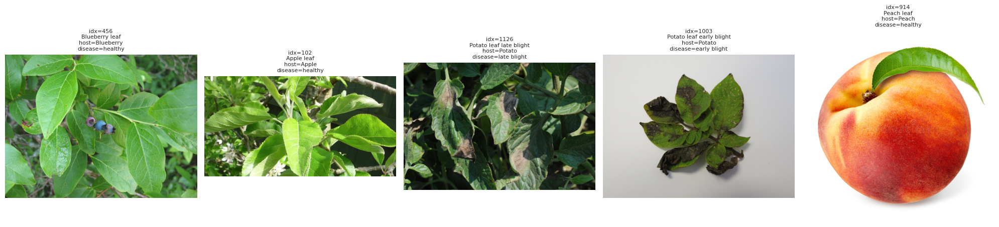

In [11]:
random_indices = random.sample(range(len(train_data)), 5)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, idx in zip(axes, random_indices):
    row = train_data[idx]
    ax.imshow(row["image"])
    ax.set_title(f"idx={idx}\n{row['class_label']}\nhost={row['host']}\n"
                 f"disease={row['disease']}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 11. Data Types / Features

In [12]:
row0 = train_data[0]

print("=== Field types ===")
for key, value in row0.items():
    print(f"{key:12s} -> {type(value)}")

print("\n=== Image details ===")
img0 = row0["image"]
print(f"Mode: {img0.mode}, Size: {img0.size}")


=== Field types ===
image        -> <class 'PIL.JpegImagePlugin.JpegImageFile'>
class_label  -> <class 'str'>
class_idx    -> <class 'int'>
host         -> <class 'str'>
disease      -> <class 'str'>
is_healthy   -> <class 'bool'>
split        -> <class 'str'>
filename     -> <class 'str'>

=== Image details ===
Mode: RGB, Size: (549, 355)


## 12. Missing, Duplicate, and Corrupt Entries — Missing Data

The dataset is small enough (2,578 images) that we check the full train split directly,
rather than sampling.


In [13]:
df_meta = pd.DataFrame({
    "class_label": train_data["class_label"],
    "host": train_data["host"],
    "disease": train_data["disease"],
    "is_healthy": train_data["is_healthy"],
    "filename": train_data["filename"],
})

print(f"Total rows checked: {len(df_meta)}")
print("\nMissing values per column:")
print(df_meta.isna().sum())

for col in ["class_label", "host", "disease", "filename"]:
    empty_count = (df_meta[col].astype(str).str.strip() == "").sum()
    print(f"Empty-string entries in '{col}': {empty_count}")


Total rows checked: 2342

Missing values per column:
class_label    0
host           0
disease        0
is_healthy     0
filename       0
dtype: int64
Empty-string entries in 'class_label': 0
Empty-string entries in 'host': 0
Empty-string entries in 'disease': 0
Empty-string entries in 'filename': 0


## 13. Corrupt Image Check

Full-split check (feasible given the small dataset size).


In [14]:
corrupt_count = 0
zero_sized_count = 0
corrupt_examples = []

for idx in range(len(train_data)):
    try:
        img = train_data[idx]["image"]
        img.load()
        w, h = img.size
        if w == 0 or h == 0:
            zero_sized_count += 1
            corrupt_examples.append(idx)
    except Exception:
        corrupt_count += 1
        corrupt_examples.append(idx)

print(f"Checked: {len(train_data)} images (full train split)")
print(f"Corrupt / unreadable images: {corrupt_count}")
print(f"Zero-sized images          : {zero_sized_count}")
if corrupt_examples:
    print(f"Example indices: {corrupt_examples[:10]}")


Checked: 2342 images (full train split)
Corrupt / unreadable images: 0
Zero-sized images          : 0


**What to do with problematic records:** drop any corrupt or zero-sized rows before
training and log how many were removed. Given the full split was checked here (not a
sample), this count is exact, not an estimate.


## 14. Duplicate Image Check (within train)

We hash every training image with a perceptual hash to find exact/near-duplicates. This
matters because a web-scraped dataset can easily contain the same photo saved under two
different filenames (common with stock-photo reposts).


In [15]:
hash_to_indices = defaultdict(list)

for idx in range(len(train_data)):
    img = train_data[idx]["image"]
    h = imagehash.average_hash(img)
    hash_to_indices[str(h)].append(idx)

dup_groups = {h: idxs for h, idxs in hash_to_indices.items() if len(idxs) > 1}
num_dup_groups = len(dup_groups)
num_dup_images = sum(len(v) for v in dup_groups.values())

print(f"Duplicate/near-duplicate groups in train: {num_dup_groups}")
print(f"Total images involved: {num_dup_images}")

if dup_groups:
    example_hash = list(dup_groups.keys())[0]
    print(f"Example group (hash={example_hash}): indices {dup_groups[example_hash]}")


Duplicate/near-duplicate groups in train: 41
Total images involved: 83
Example group (hash=0f0f07a727636174): indices [11, 50]


**Why this matters:** a duplicate that ends up counted twice in the training set adds
mild redundancy (usually harmless). A duplicate that appears in *both* train and test is
a real leakage risk — checked next, in Section 15.


## 15. Data Leakage Analysis — Train vs. Test Duplicate Check

**Why this section differs from a typical PlantVillage-style notebook:** PlantDoc has
no `leaf_id` — each image is an independently scraped photo, not one of several photos
of the same physical leaf. So there is no leaf-grouping step to perform here. Instead,
the realistic leakage risk for a scraped dataset is the *same image* (or a
near-duplicate) appearing in both the train and test split. We check that directly.


In [48]:
if test_data is not None:
    test_hashes = {}
    for idx in range(len(test_data)):
        img = test_data[idx]["image"]
        h = str(imagehash.average_hash(img))
        test_hashes.setdefault(h, []).append(idx)

    train_hashes = set(hash_to_indices.keys())  # computed in Section 14
    test_hash_set = set(test_hashes.keys())

    overlap_hashes = train_hashes & test_hash_set
    print(f"Hashes appearing in BOTH train and test: {len(overlap_hashes)}")

    if overlap_hashes:
        example = list(overlap_hashes)[0]
        print(f"Example overlapping hash: train indices {hash_to_indices[example]}, "
              f"test indices {test_hashes[example]}")

    else:
        print("No exact-duplicate images found across train and test (hash-based check).")
else:
    print("No test split available — skipping train/test overlap check.")


Hashes appearing in BOTH train and test: 14
Example overlapping hash: train indices [1894], test indices [176]


## 16. Class Distribution

Full-split class counts (cheap metadata operation).


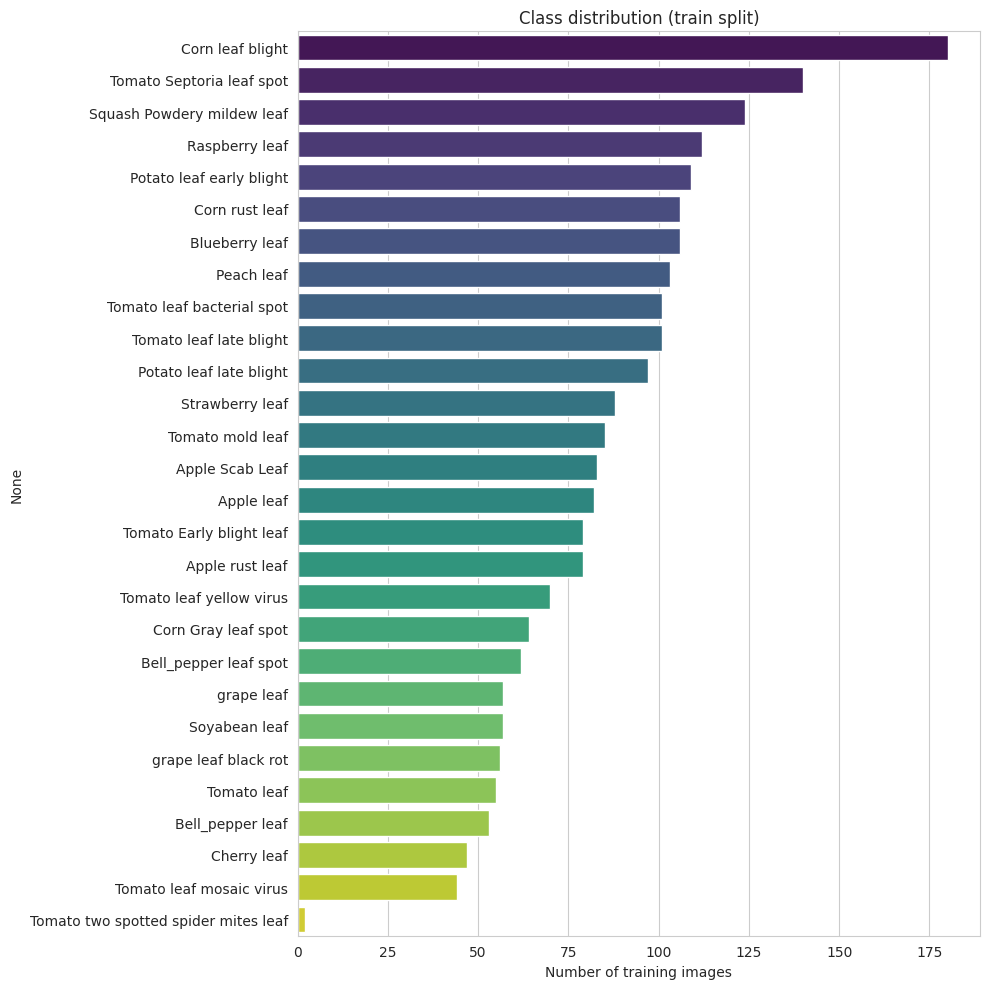

Largest class : Corn leaf blight (180 images)
Smallest class: Tomato two spotted spider mites leaf (2 images)
Imbalance ratio (largest/smallest): 90.0


In [17]:
label_counts = pd.Series(train_data["class_label"]).value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x=label_counts.values, y=label_counts.index, palette="viridis")
plt.xlabel("Number of training images")
plt.title("Class distribution (train split)")
plt.tight_layout()
plt.show()

largest_class = label_counts.idxmax()
smallest_class = label_counts.idxmin()
imbalance_ratio = label_counts.max() / label_counts.min()

print(f"Largest class : {largest_class} ({label_counts.max()} images)")
print(f"Smallest class: {smallest_class} ({label_counts.min()} images)")
print(f"Imbalance ratio (largest/smallest): {imbalance_ratio:.1f}")


**Note the orphan class:** `Tomato two spotted spider mites leaf` has only 2 training
images and 0 test images (per the dataset documentation) — check whether it shows up as
the smallest class above. This class cannot be evaluated on the shipped test split at
all. Two reasonable options, per the "do not remove data automatically" rule: (1) keep
it and accept it will only ever appear in training (never evaluated), or (2) drop it
explicitly to match the widely-cited 27-class version used in the literature. This
decision should be made explicitly in Section 28, not silently.


## 17. Image Dimensions

Documentation states widths range 189–4,000px and heights 194–4,272px — i.e. this
dataset is deliberately heterogeneous. We verify directly.


             width       height
count  2342.000000  2342.000000
mean   1063.708796   912.032451
std     856.057583   750.399596
min     115.000000    85.000000
25%     500.000000   405.250000
50%     800.000000   666.000000
75%    1300.000000  1172.500000
max    6000.000000  6000.000000

All images the same size: False


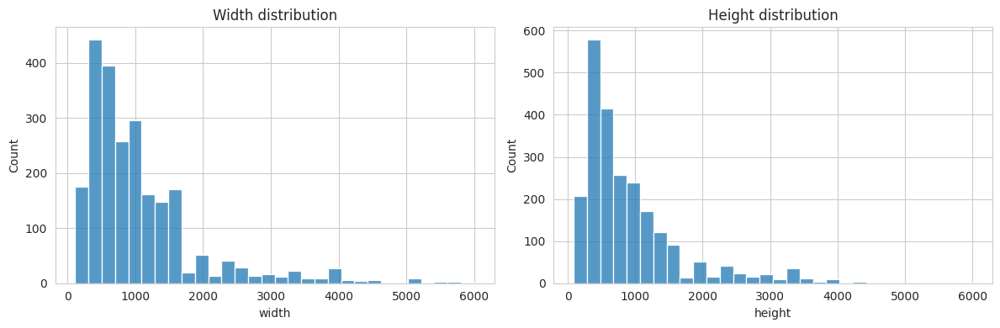

In [18]:
widths, heights = [], []
for idx in range(len(train_data)):
    w, h = train_data[idx]["image"].size
    widths.append(w)
    heights.append(h)

dim_df = pd.DataFrame({"width": widths, "height": heights})
print(dim_df.describe())

same_size = (dim_df["width"].nunique() == 1) and (dim_df["height"].nunique() == 1)
print(f"\nAll images the same size: {same_size}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(dim_df["width"], bins=30, ax=axes[0])
axes[0].set_title("Width distribution")
sns.histplot(dim_df["height"], bins=30, ax=axes[1])
axes[1].set_title("Height distribution")
plt.tight_layout()
plt.show()


**Choosing a target CNN resolution:** given the large size range, every image will be
resized substantially regardless of choice. **128×128** is proposed as the default —
fast to train, and disease symptoms in these field photos are generally large relative
to the frame (unlike PlantVillage's tight leaf crops). Revisit if the sample grid in
Section 19 shows fine detail is lost.


## 18. Channel Analysis

Documentation warns of some CMYK images mixed in with RGB — we verify and make sure the
preprocessing plan accounts for it.


In [19]:
mode_counts = Counter()
for idx in range(len(train_data)):
    mode_counts[train_data[idx]["image"].mode] += 1

print("Image mode counts (full train split):")
for mode, count in mode_counts.items():
    print(f"  {mode}: {count}")

all_rgb = set(mode_counts.keys()) <= {"RGB"}
print(f"\nAll images are RGB: {all_rgb}")
if not all_rgb:
    print("Non-RGB images found — every image must be .convert('RGB') during "
          "preprocessing (Section 28) to guarantee a consistent 3-channel CNN input.")


Image mode counts (full train split):
  RGB: 2331
  L: 1
  CMYK: 5
  RGBA: 5

All images are RGB: False
Non-RGB images found — every image must be .convert('RGB') during preprocessing (Section 28) to guarantee a consistent 3-channel CNN input.


## 19. Sample Grid Per Class

In [20]:
class_example_idx = {}
for idx in range(len(train_data)):
    lbl = train_data[idx]["class_label"]
    if lbl not in class_example_idx:
        class_example_idx[lbl] = idx
    if len(class_example_idx) == len(class_names):
        break

print(f"Found example images for {len(class_example_idx)} / {len(class_names)} classes.")


Found example images for 28 / 28 classes.


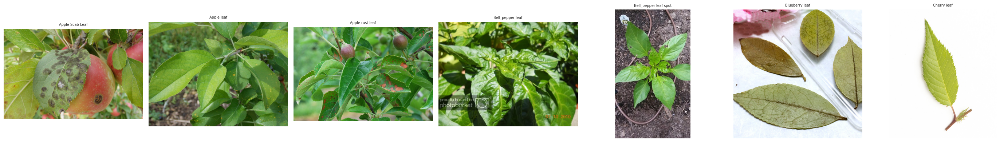

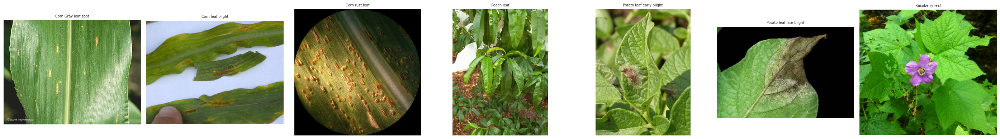

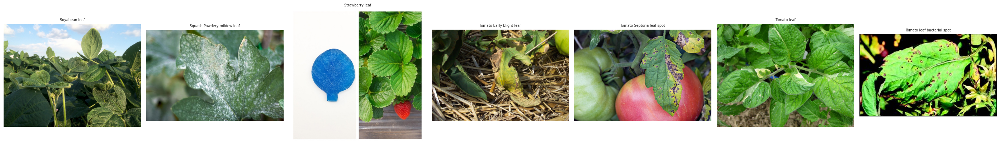

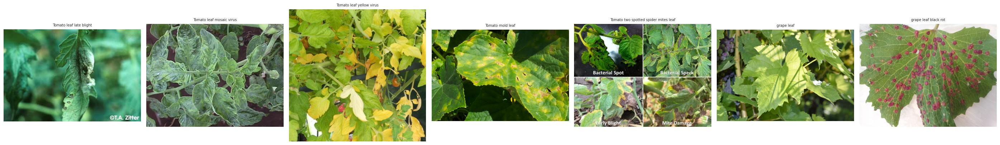

In [21]:
CLASSES_PER_FIGURE = 7
class_labels_sorted = sorted(class_example_idx.keys())

for start in range(0, len(class_labels_sorted), CLASSES_PER_FIGURE):
    chunk = class_labels_sorted[start: start + CLASSES_PER_FIGURE]
    fig, axes = plt.subplots(1, len(chunk), figsize=(4 * len(chunk), 4))
    if len(chunk) == 1:
        axes = [axes]
    for ax, label in zip(axes, chunk):
        idx = class_example_idx[label]
        ax.imshow(train_data[idx]["image"])
        ax.set_title(label, fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 20. Pixel Intensity Analysis

Sampled 600 images (resized to 64x64) for intensity analysis.


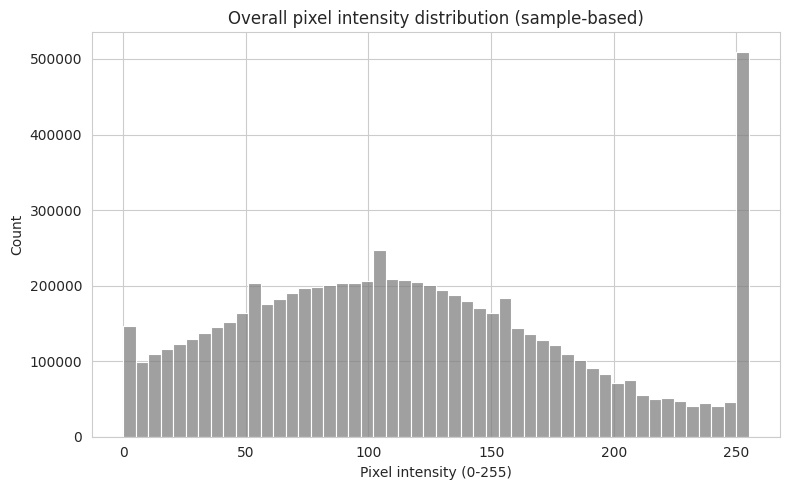

In [22]:
PIXEL_SAMPLE_SIZE = min(600, len(train_data))
pixel_indices = random.sample(range(len(train_data)), PIXEL_SAMPLE_SIZE)

all_pixels = []
for idx in pixel_indices:
    img = train_data[idx]["image"].convert("RGB").resize((64, 64))
    all_pixels.append(np.array(img).reshape(-1, 3))

all_pixels = np.vstack(all_pixels)
print(f"Sampled {PIXEL_SAMPLE_SIZE} images (resized to 64x64) for intensity analysis.")

plt.figure(figsize=(8, 5))
sns.histplot(all_pixels.flatten(), bins=50, color="gray")
plt.title("Overall pixel intensity distribution (sample-based)")
plt.xlabel("Pixel intensity (0-255)")
plt.tight_layout()
plt.show()


## 21. RGB Analysis

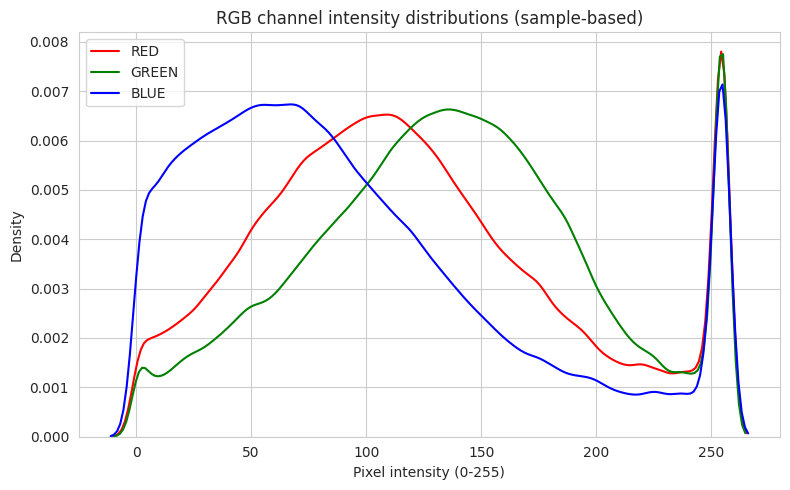

Mean R: 120.77
Mean G: 136.76
Mean B: 95.87


In [23]:
plt.figure(figsize=(8, 5))
for i, color in enumerate(["red", "green", "blue"]):
    sns.kdeplot(all_pixels[:, i], color=color, label=color.upper())
plt.title("RGB channel intensity distributions (sample-based)")
plt.xlabel("Pixel intensity (0-255)")
plt.legend()
plt.tight_layout()
plt.show()

for i, color in enumerate(["R", "G", "B"]):
    print(f"Mean {color}: {all_pixels[:, i].mean():.2f}")


**Interpretation:** diseased tissue typically shifts color away from the healthy
green baseline (browning, yellowing, spotting). Because PlantDoc images include varied
real-world backgrounds (soil, other foliage, hands, hardscape), the color distribution
here is expected to be noisier than a lab dataset like PlantVillage — worth keeping in
mind when judging how "clean" a color-based signal the CNN can learn.


## 22. Mean Image Per Class

In [24]:
MEAN_IMG_SIZE = (64, 64)
class_to_indices = defaultdict(list)
for idx in range(len(train_data)):
    class_to_indices[train_data[idx]["class_label"]].append(idx)

mean_images = {}
for label, idxs in class_to_indices.items():
    arrs = []
    for idx in idxs:
        img = train_data[idx]["image"].convert("RGB").resize(MEAN_IMG_SIZE)
        arrs.append(np.array(img, dtype=np.float32))
    mean_images[label] = np.mean(arrs, axis=0).astype(np.uint8)

print(f"Computed mean images for {len(mean_images)} classes.")


Computed mean images for 28 classes.


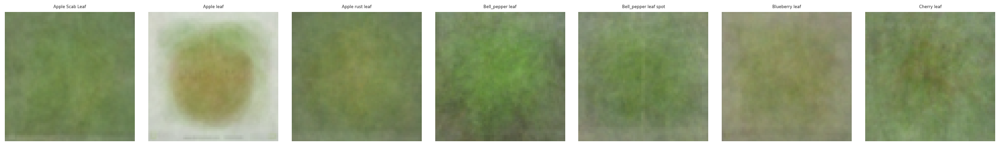

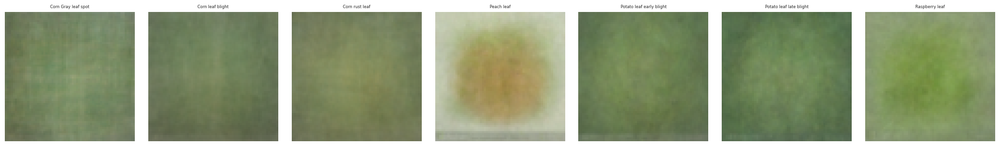

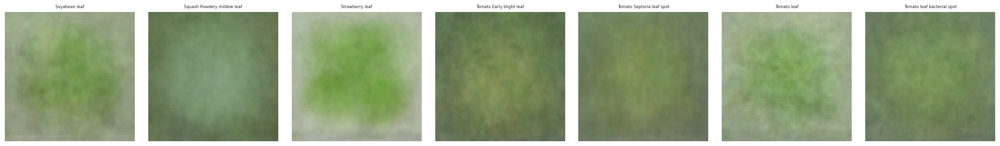

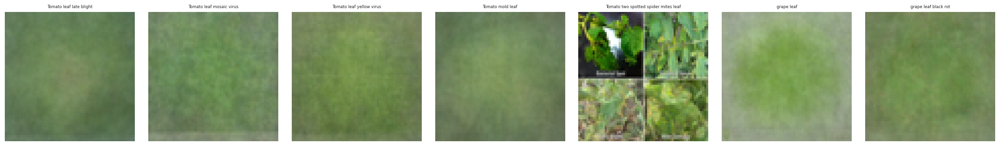

In [25]:
CLASSES_PER_FIGURE = 7
labels_sorted = sorted(mean_images.keys())

for start in range(0, len(labels_sorted), CLASSES_PER_FIGURE):
    chunk = labels_sorted[start: start + CLASSES_PER_FIGURE]
    fig, axes = plt.subplots(1, len(chunk), figsize=(3 * len(chunk), 3))
    if len(chunk) == 1:
        axes = [axes]
    for ax, label in zip(axes, chunk):
        ax.imshow(mean_images[label])
        ax.set_title(label, fontsize=6)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


**Interpretation (finalize after viewing the figures):** unlike PlantVillage's sharp
mean images (a sign of tightly controlled, consistent framing), PlantDoc's mean images
are likely to look blurred/washed-out — a direct visual signature of the heterogeneous
framing, backgrounds, and camera distances documented for this dataset. This is expected,
not a bug, and it supports using several convolutional layers plus augmentation
(Section 28) so the CNN doesn't overfit to any one photo style.


## 23. Brightness Analysis

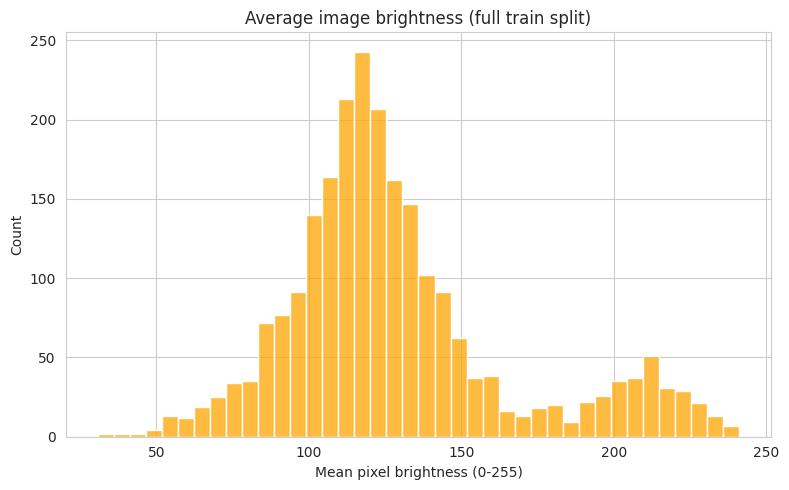

Mean : 128.70
Std  : 37.80
Range: [30.81, 241.15]


In [26]:
brightness_values = []
for idx in range(len(train_data)):
    img = train_data[idx]["image"].convert("L").resize((64, 64))
    brightness_values.append(np.array(img, dtype=np.float32).mean())

brightness_values = np.array(brightness_values)

plt.figure(figsize=(8, 5))
sns.histplot(brightness_values, bins=40, color="orange")
plt.title("Average image brightness (full train split)")
plt.xlabel("Mean pixel brightness (0-255)")
plt.tight_layout()
plt.show()

print(f"Mean : {brightness_values.mean():.2f}")
print(f"Std  : {brightness_values.std():.2f}")
print(f"Range: [{brightness_values.min():.2f}, {brightness_values.max():.2f}]")


**Discussion:** given the dataset already spans many real-world lighting conditions
by construction, a wide spread here is expected. If the spread is already wide, heavy
brightness augmentation is less necessary — the raw data already covers this variation.


## 24. Aspect Ratio Analysis

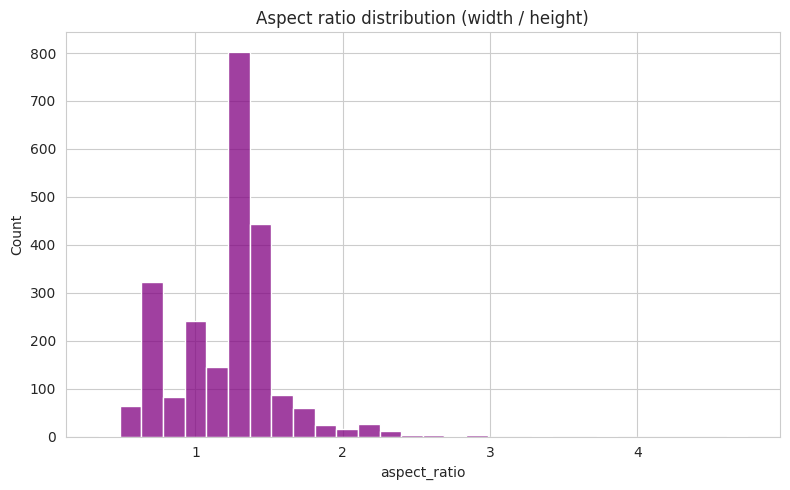

count    2342.000000
mean        1.244055
std         0.363991
min         0.338983
25%         1.000000
50%         1.333333
75%         1.442218
max         4.747475
Name: aspect_ratio, dtype: float64

Approximately square images: 11.8%


In [27]:
dim_df["aspect_ratio"] = dim_df["width"] / dim_df["height"]

plt.figure(figsize=(8, 5))
sns.histplot(dim_df["aspect_ratio"], bins=30, color="purple")
plt.title("Aspect ratio distribution (width / height)")
plt.tight_layout()
plt.show()

print(dim_df["aspect_ratio"].describe())
near_square = ((dim_df["aspect_ratio"] > 0.9) & (dim_df["aspect_ratio"] < 1.1)).mean()
print(f"\nApproximately square images: {near_square * 100:.1f}%")


**Implication:** if a meaningful share of images are clearly non-square, resizing
directly to a square target will distort leaf shape. Padding to a square canvas before
resizing is the safer default here, given the documented resolution range is wide.


## 25. Background / Dataset Bias Discussion

Unlike PlantVillage, PlantDoc's backgrounds are *intentionally* varied (soil, other
plants, hands, indoor/outdoor settings) — this is the dataset's whole design purpose. We
check this directly using a simple corner-color proxy.


Corner (background-proxy) color spread:
  R std: 60.6
  G std: 55.1
  B std: 66.1


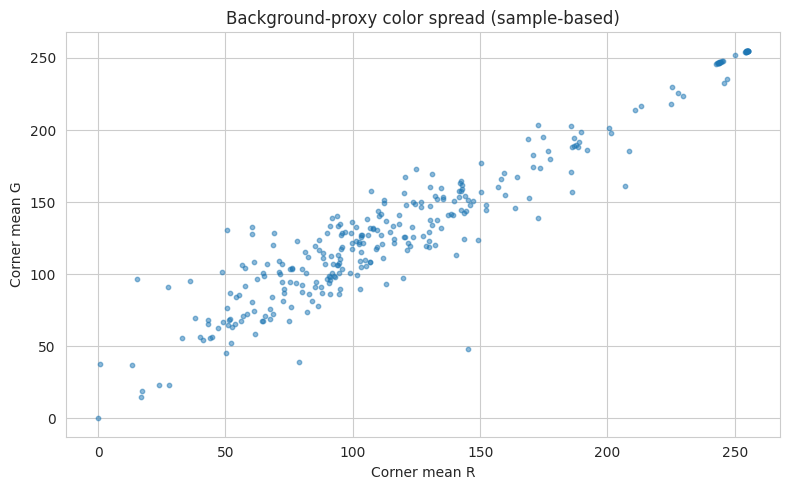

In [28]:
BG_SAMPLE_SIZE = min(300, len(train_data))
bg_indices = random.sample(range(len(train_data)), BG_SAMPLE_SIZE)

corner_colors = []
for idx in bg_indices:
    img = train_data[idx]["image"].convert("RGB").resize((64, 64))
    arr = np.array(img)
    patch = np.concatenate([
        arr[:6, :6].reshape(-1, 3), arr[:6, -6:].reshape(-1, 3),
        arr[-6:, :6].reshape(-1, 3), arr[-6:, -6:].reshape(-1, 3),
    ], axis=0)
    corner_colors.append(patch.mean(axis=0))

corner_colors = np.array(corner_colors)

print("Corner (background-proxy) color spread:")
print(f"  R std: {corner_colors[:,0].std():.1f}")
print(f"  G std: {corner_colors[:,1].std():.1f}")
print(f"  B std: {corner_colors[:,2].std():.1f}")

plt.figure(figsize=(8, 5))
plt.scatter(corner_colors[:, 0], corner_colors[:, 1], s=10, alpha=0.5)
plt.xlabel("Corner mean R")
plt.ylabel("Corner mean G")
plt.title("Background-proxy color spread (sample-based)")
plt.tight_layout()
plt.show()


**Discussion:** a wide, scattered plot (high std) confirms varied backgrounds, which
is good news for real-world generalization — the CNN is less likely to key on a single
background color as a shortcut, compared to a controlled dataset. The remaining bias risk
here is different: photography style, source website, or stock-photo watermarking could
still correlate with class if certain classes were scraped predominantly from one source.


## 26. Train / Validation / Test Split Plan

**Test set:** we use the dataset's shipped `test` split as-is, and only after removing
any images identified as exact train/test duplicates in Section 15.

**Validation set:** since there is no `leaf_id` (or any other grouping key) in this
dataset, a plain **stratified random split by class** on the training data is the
correct approach here — stratification keeps each class's proportion consistent between
the new train and validation subsets, which matters given the class imbalance already
observed in Section 16.


In [29]:
VAL_FRACTION = 0.15
rng = np.random.RandomState(SEED)

train_labels = np.array(train_data["class_label"])
val_idx_list = []
train_idx_list = []

for label in class_names:
    label_indices = np.where(train_labels == label)[0]
    if len(label_indices) == 0:
        continue
    shuffled = rng.permutation(label_indices)
    n_val = max(1, int(len(shuffled) * VAL_FRACTION)) if len(shuffled) > 1 else 0
    val_idx_list.extend(shuffled[:n_val])
    train_idx_list.extend(shuffled[n_val:])

val_idx_list = np.array(sorted(val_idx_list))
train_idx_list = np.array(sorted(train_idx_list))

print(f"Training rows  : {len(train_idx_list)}")
print(f"Validation rows: {len(val_idx_list)}")

overlap = set(val_idx_list) & set(train_idx_list)
print(f"Overlap check (must be 0): {len(overlap)}")


Training rows  : 2003
Validation rows: 339
Overlap check (must be 0): 0


**Note on the orphan class:** if `Tomato two spotted spider mites leaf` has only 2
training images, stratified splitting will place at most 1 in validation (or none) —
this class's validation/test signal will be extremely weak regardless of split strategy.
This should be called out explicitly in the model evaluation notebook.


## 27. Three Important EDA Findings

**Finding 1: Duplicate images inflate training data and leak into the test set.**

*Evidence from EDA:* Section 14 found 41 duplicate/near-duplicate groups within the
training split (83 images total). Section 15 found 14 exact-duplicate image hashes
appearing in BOTH train and test.

*Effect on model design:* The 14 train-side images that duplicate a test image must be
removed from training before fitting the model, or the reported test accuracy would be
partly measuring memorization rather than generalization.

**Finding 2: The dataset is severely imbalanced, with one unusable orphan class.**

*Evidence from EDA:* Section 16 found an imbalance ratio of 90.0 — the largest class
(`Corn leaf blight`, 180 images) has 90x more training images than the smallest
(`Tomato two spotted spider mites leaf`, 2 images). That smallest class also has 0 test
images (documented dataset caveat), so it can never be evaluated.

*Effect on model design:* Accuracy alone would be misleading on this class distribution.
Per-class precision/recall/F1 and a confusion matrix are required. The orphan class is
dropped before training (Section 28/32) since it cannot be meaningfully learned (2
examples) or evaluated (0 test examples) — matching the 27-class standard used in the
literature (Singh et al. 2020).

**Finding 3: Images are genuinely heterogeneous — size, aspect ratio, background, and
even color mode all vary widely.**

*Evidence from EDA:* Section 17 found image widths ranging from 115px to 6,000px (mean
~1,064px). Section 24 found only 11.8% of images are approximately square (mean aspect
ratio 1.24, range 0.34–4.75). Section 18 found 11 non-RGB images (1 grayscale, 5 CMYK, 5
RGBA) mixed in with 2,331 RGB images. Section 25 found high background-color spread
(corner-patch RGB std ≈ 60.6 / 55.1 / 66.1), and Section 22's mean-per-class images were
visibly blurred/washed out rather than sharp, confirming inconsistent framing.

*Effect on model design:* Every image must be explicitly `.convert("RGB")`'d before
resizing (to handle the non-RGB images safely), resized to a fixed input size, and
trained with moderate geometric augmentation (flip/rotation/zoom) so the CNN doesn't
overfit to any single framing or background style — there is no consistent background
shortcut for it to exploit here, unlike a lab dataset.


## 28. Preprocessing Decisions

The preprocessing choices below are the decisions actually implemented in the CNN:

1. Convert every image to RGB.
2. Resize every image to 128×128 pixels.
3. Rescale pixel values to [0, 1] inside the Keras model.
4. Encode labels from the observed class names; the output dimension is derived from the retained classes.
5. Drop the observed orphan class `Tomato two spotted spider mites leaf` because it has 2 training images and 0 test images.
6. Remove the 14 training-side images whose hashes also occur in the test split.
7. Use the stratified 15% validation split already computed in this notebook.
8. Use horizontal flip, small rotation, moderate zoom and translation. Heavy colour jitter is not used because colour can carry disease information.


## 29. CNN Architecture Plan

```
Input: 128 x 128 x 3
  -> Conv2D(32, 3x3) + ReLU -> MaxPooling2D(2x2)
  -> Conv2D(64, 3x3) + ReLU -> MaxPooling2D(2x2)
  -> Conv2D(128, 3x3) + ReLU -> MaxPooling2D(2x2)
  -> Flatten (or GlobalAveragePooling2D)
  -> Dense(128, ReLU)
  -> Dropout(0.3-0.5)
  -> Dense(num_classes, Softmax)
```

**Layer explanations:**
- **Conv2D + ReLU:** detects local visual patterns (edges, color blobs, then more complex
  disease-spot shapes as layers stack).
- **MaxPooling2D:** shrinks feature maps, keeping the strongest signal — also adds some
  tolerance to the leaf not being centered, useful given this dataset's varied framing.
- **Flatten/GlobalAveragePooling2D:** turns 2D features into a vector for the Dense layers.
- **Dense(128):** combines extracted features into a decision.
- **Dropout:** randomly disables neurons during training to reduce overfitting — important
  given the small dataset size (2,342 training images across 28 classes).
- **Dense(num_classes, Softmax):** output layer sized to the actual number of classes
  confirmed in Section 8, not hard-coded.


## 30. How EDA Findings Influenced Model Design

**Finding 1:** 14 exact-duplicate images were found across train and test (Section 15).

*Model decision:* Those 14 training-side images are removed before training (Section 32).

*Reason:* Prevents memorized test images from inflating reported accuracy.

**Finding 2:** Class imbalance ratio of 90.0, with one orphan class that has 0 test
images (Section 16/27).

*Model decision:* Evaluate with precision/recall/F1 and a per-class confusion matrix,
not accuracy alone (Section 36). The orphan class is dropped, reducing the problem to 27
classes (Section 32). Class weighting is applied during training to counter the
remaining imbalance.

*Reason:* A 28-class, 90x-imbalanced, partly test-less dataset would produce a
misleadingly high accuracy number if evaluated naively, and the orphan class cannot be
scored on the test set regardless of how well it's learned.

**Finding 3:** Images vary widely in size, aspect ratio, background, and color mode
(Section 17/18/24/25/27).

*Model decision:* All images are converted to RGB and resized to a fixed 128x128 input;
moderate flip/rotation/zoom/translation augmentation and dropout are used in the CNN
(Section 32/33).

*Reason:* Helps the CNN generalize across PlantDoc's genuinely varied real-world photo
conditions, rather than overfitting to a narrow set of framing/background styles.


## 31. Conclusion

The EDA established the dataset facts used by the CNN: 2,342 training images, 236 test images, 28 observed classes, 14 train/test duplicate hashes, a 90.0 largest-to-smallest class imbalance ratio, mixed image modes, and substantial variation in image geometry. These findings motivate RGB conversion, fixed-size resizing, leakage removal, class weighting, augmentation, and evaluation with per-class precision/recall/F1 rather than accuracy alone.

The CNN and final report are generated from the observed outputs of the subsequent training and evaluation cells; no manual placeholder values are used.


## 32. CNN Implementation

We now build the CNN using TensorFlow/Keras, applying the preprocessing decisions from
Section 28: drop the orphan class, remove the 14 train/test duplicate images, convert
every image to RGB, and resize to a fixed input size.

This section reuses variables already computed earlier in this notebook: `train_data`,
`test_data`, `class_names`, `train_labels`, `train_idx_list`, `val_idx_list`,
`hash_to_indices`, and `overlap_hashes` (Sections 6, 8, 14, 15, 16, 26). Run the whole
notebook top to bottom for this section to work.


In [30]:
!pip install -q tensorflow scikit-learn


In [31]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [32]:
IMG_SIZE = 128
ORPHAN_CLASS = "Tomato two spotted spider mites leaf"

# Drop the orphan class (Section 27/28 decision: 2 train images, 0 test images)
kept_class_names = [c for c in class_names if c != ORPHAN_CLASS]
old_to_new = {name: i for i, name in enumerate(kept_class_names)}
NUM_CLASSES = len(kept_class_names)
print(f"Classes kept: {NUM_CLASSES} (dropped orphan class '{ORPHAN_CLASS}')")


Classes kept: 27 (dropped orphan class 'Tomato two spotted spider mites leaf')


In [33]:
# Build the set of training-side indices that duplicate a test image (Section 15)
leak_train_indices = set()
for h in overlap_hashes:
    leak_train_indices.update(hash_to_indices[h])
print(f"Train images to drop as train/test duplicates: {len(leak_train_indices)}")

def filter_indices(idx_array):
    kept = []
    for idx in idx_array:
        idx = int(idx)
        if train_labels[idx] == ORPHAN_CLASS:
            continue
        if idx in leak_train_indices:
            continue
        kept.append(idx)
    return kept

train_final_idx = filter_indices(train_idx_list)
val_final_idx = filter_indices(val_idx_list)

print(f"Final training rows  : {len(train_final_idx)} (was {len(train_idx_list)})")
print(f"Final validation rows: {len(val_final_idx)} (was {len(val_idx_list)})")


Train images to drop as train/test duplicates: 15
Final training rows  : 1990 (was 2003)
Final validation rows: 335 (was 339)


In [34]:
test_labels_arr = np.array(test_data["class_label"])
test_keep_idx = [i for i, l in enumerate(test_labels_arr) if l != ORPHAN_CLASS]
print(f"Test rows kept: {len(test_keep_idx)} (was {len(test_data)})")


Test rows kept: 236 (was 236)


In [35]:
def build_arrays(hf_dataset, indices, label_array, class_map, img_size=IMG_SIZE):
    """Decode, RGB-convert, resize, and stack images + integer labels."""
    X = np.zeros((len(indices), img_size, img_size, 3), dtype=np.uint8)
    y = np.zeros((len(indices),), dtype=np.int64)
    for i, idx in enumerate(indices):
        img = hf_dataset[int(idx)]["image"].convert("RGB").resize((img_size, img_size))
        X[i] = np.array(img, dtype=np.uint8)
        y[i] = class_map[label_array[idx]]
    return X, y

print("Building training array...")
X_train, y_train = build_arrays(train_data, train_final_idx, train_labels, old_to_new)
print("Building validation array...")
X_val, y_val = build_arrays(train_data, val_final_idx, train_labels, old_to_new)
print("Building test array...")
X_test, y_test = build_arrays(test_data, test_keep_idx, test_labels_arr, old_to_new)

print(f"\nX_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}  y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  y_test : {y_test.shape}")


Building training array...
Building validation array...
Building test array...

X_train: (1990, 128, 128, 3)  y_train: (1990,)
X_val  : (335, 128, 128, 3)  y_val  : (335,)
X_test : (236, 128, 128, 3)  y_test : (236,)


In [36]:
# Class weights to counter the imbalance found in Section 16/27 (ratio 90.0)
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train,
)
class_weight_dict = {i: w for i, w in enumerate(class_weight_values)}
print("Class weight range:", min(class_weight_dict.values()), "to",
      max(class_weight_dict.values()))


Class weight range: 0.48172355361897845 to 1.939571150097466


## 33. Model Definition

Architecture follows the plan from Section 29: three Conv2D+MaxPooling blocks, a Dense
layer, Dropout, and a Softmax output sized to `NUM_CLASSES` (confirmed from data, not
hard-coded). Rescaling and augmentation are built into the model itself as Keras layers,
so they only apply during training, never at inference.


In [37]:
def build_model(num_classes, dropout_rate=0.4, augment=True, conv_filters=(32, 64, 128)):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Rescaling(1. / 255)(inputs)

    if augment:
        x = layers.RandomFlip("horizontal")(x)
        x = layers.RandomRotation(0.08)(x)
        x = layers.RandomZoom(0.10)(x)
        x = layers.RandomTranslation(0.10, 0.10)(x)

    for filters in conv_filters:
        x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
        x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)

sample_model = build_model(NUM_CLASSES)
sample_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 128, 128, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,291,163 (16.37 MB)

 Trainable params: 4,291,163 (16.37 MB)

 Non-trainable params: 0 (0.00 B)

## 34. Training — Hyperparameter Experiments

We train three configurations that vary learning rate, dropout, and optimizer, and
compare their validation accuracy/loss curves. Each uses `EarlyStopping` (on validation
loss) and `ReduceLROnPlateau`, with a fixed random seed and a capped number of epochs so
this stays practical to run in Colab.


In [38]:
EPOCHS_CAP = 30
BATCH_SIZE = 32

configs = {
    "baseline (lr=1e-3, dropout=0.4, Adam)": dict(
        lr=1e-3, dropout=0.4, optimizer="adam"),
    "lower_lr (lr=3e-4, dropout=0.4, Adam)": dict(
        lr=3e-4, dropout=0.4, optimizer="adam"),
    "higher_dropout (lr=1e-3, dropout=0.6, Adam)": dict(
        lr=1e-3, dropout=0.6, optimizer="adam"),
}

histories = {}
trained_models = {}

for name, cfg in configs.items():
    print(f"\n=== Training: {name} ===")
    tf.keras.utils.set_random_seed(SEED)

    model = build_model(NUM_CLASSES, dropout_rate=cfg["dropout"], augment=True)
    opt = optimizers.Adam(learning_rate=cfg["lr"])
    model.compile(optimizer=opt,
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6,
                                          restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                              patience=3, min_lr=1e-6),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS_CAP,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1,
    )

    histories[name] = history.history
    trained_models[name] = model



=== Training: baseline (lr=1e-3, dropout=0.4, Adam) ===
Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.0462 - loss: 3.3087 - val_accuracy: 0.0597 - val_loss: 3.2512 - learning_rate: 0.0010
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0543 - loss: 3.2527 - val_accuracy: 0.0448 - val_loss: 3.2168 - learning_rate: 0.0010
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0693 - loss: 3.2060 - val_accuracy: 0.0896 - val_loss: 3.1895 - learning_rate: 0.0010
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0809 - loss: 3.1802 - val_accuracy: 0.1045 - val_loss: 3.1194 - learning_rate: 0.0010
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0955 - loss: 3.1257 - val_accuracy: 0.0925 - val_loss: 3.1039 - learning_rate: 0.0010
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.1090 - loss: 3.0455 - val_accuracy: 0.1224 - val_loss: 3.0269 - learning_rate: 0.0010
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━

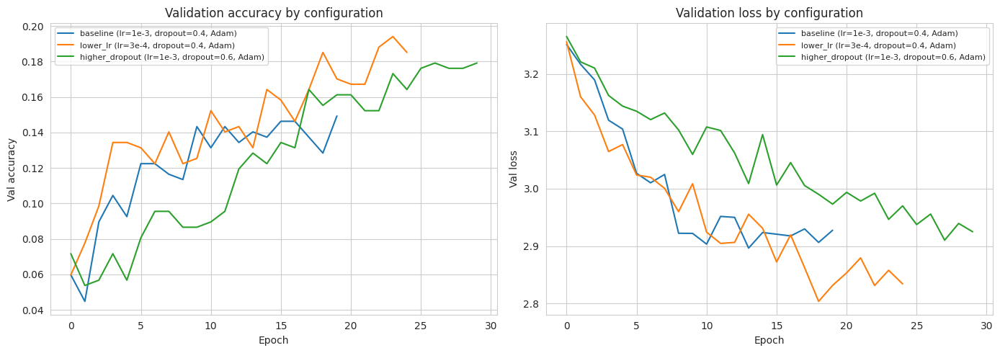

baseline (lr=1e-3, dropout=0.4, Adam)         best val_acc=0.149  best val_loss=2.897
lower_lr (lr=3e-4, dropout=0.4, Adam)         best val_acc=0.194  best val_loss=2.804
higher_dropout (lr=1e-3, dropout=0.6, Adam)   best val_acc=0.179  best val_loss=2.910


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, hist in histories.items():
    axes[0].plot(hist["val_accuracy"], label=name)
    axes[1].plot(hist["val_loss"], label=name)

axes[0].set_title("Validation accuracy by configuration")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Val accuracy")
axes[0].legend(fontsize=8)

axes[1].set_title("Validation loss by configuration")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val loss")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

for name, hist in histories.items():
    best_val_acc = max(hist["val_accuracy"])
    best_val_loss = min(hist["val_loss"])
    print(f"{name:45s} best val_acc={best_val_acc:.3f}  best val_loss={best_val_loss:.3f}")


The comparison below is generated directly from the three completed training histories. The selected configuration is determined from the highest observed validation accuracy, and the final DOCX report records the actual values.


In [40]:
BEST_CONFIG_NAME = max(histories, key=lambda k: max(histories[k]["val_accuracy"]))
best_model = trained_models[BEST_CONFIG_NAME]
print(f"Selected best configuration: {BEST_CONFIG_NAME}")


Selected best configuration: lower_lr (lr=3e-4, dropout=0.4, Adam)


## 35. Training Curves — Selected Model

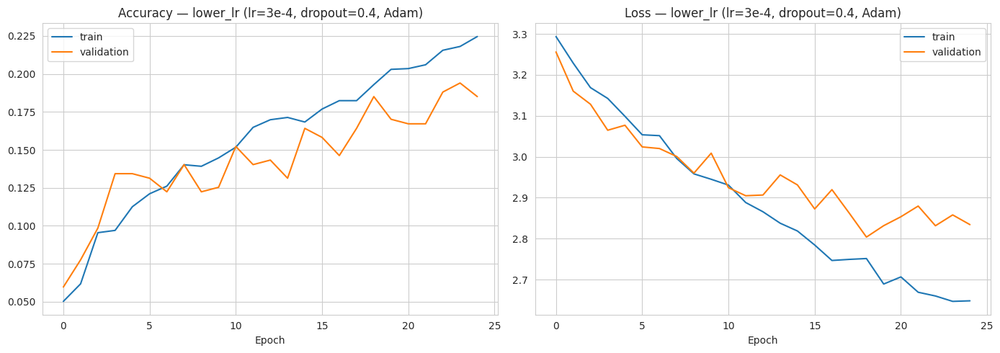

In [41]:
best_hist = histories[BEST_CONFIG_NAME]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(best_hist["accuracy"], label="train")
axes[0].plot(best_hist["val_accuracy"], label="validation")
axes[0].set_title(f"Accuracy — {BEST_CONFIG_NAME}")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(best_hist["loss"], label="train")
axes[1].plot(best_hist["val_loss"], label="validation")
axes[1].set_title(f"Loss — {BEST_CONFIG_NAME}")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 36. Test Evaluation

The test set (Section 32) has already had the orphan class removed; it was left
otherwise untouched (per Section 26's rule — the test set is only used once, here).


In [42]:
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test loss    : {test_loss:.3f}")

y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred_conf = np.max(y_pred_probs, axis=1)


Test accuracy: 0.127
Test loss    : 2.972


## 37. Classification Report (Precision, Recall, F1)

Per Section 27/30, accuracy alone is not sufficient given the class imbalance — this
report gives per-class precision/recall/F1, plus macro and weighted averages.


In [43]:
report_str = classification_report(
    y_test, y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=kept_class_names,
    zero_division=0,
)
print(report_str)


                            precision    recall  f1-score   support

           Apple Scab Leaf       0.00      0.00      0.00        10
                Apple leaf       0.06      0.11      0.08         9
           Apple rust leaf       0.00      0.00      0.00        10
          Bell_pepper leaf       0.04      0.12      0.06         8
     Bell_pepper leaf spot       0.00      0.00      0.00         9
            Blueberry leaf       0.00      0.00      0.00        11
               Cherry leaf       0.25      0.10      0.14        10
       Corn Gray leaf spot       0.00      0.00      0.00         4
          Corn leaf blight       0.20      0.08      0.12        12
            Corn rust leaf       0.20      0.10      0.13        10
                Peach leaf       0.00      0.00      0.00         9
  Potato leaf early blight       0.33      0.12      0.18         8
   Potato leaf late blight       0.00      0.00      0.00         8
            Raspberry leaf       0.00      0.00

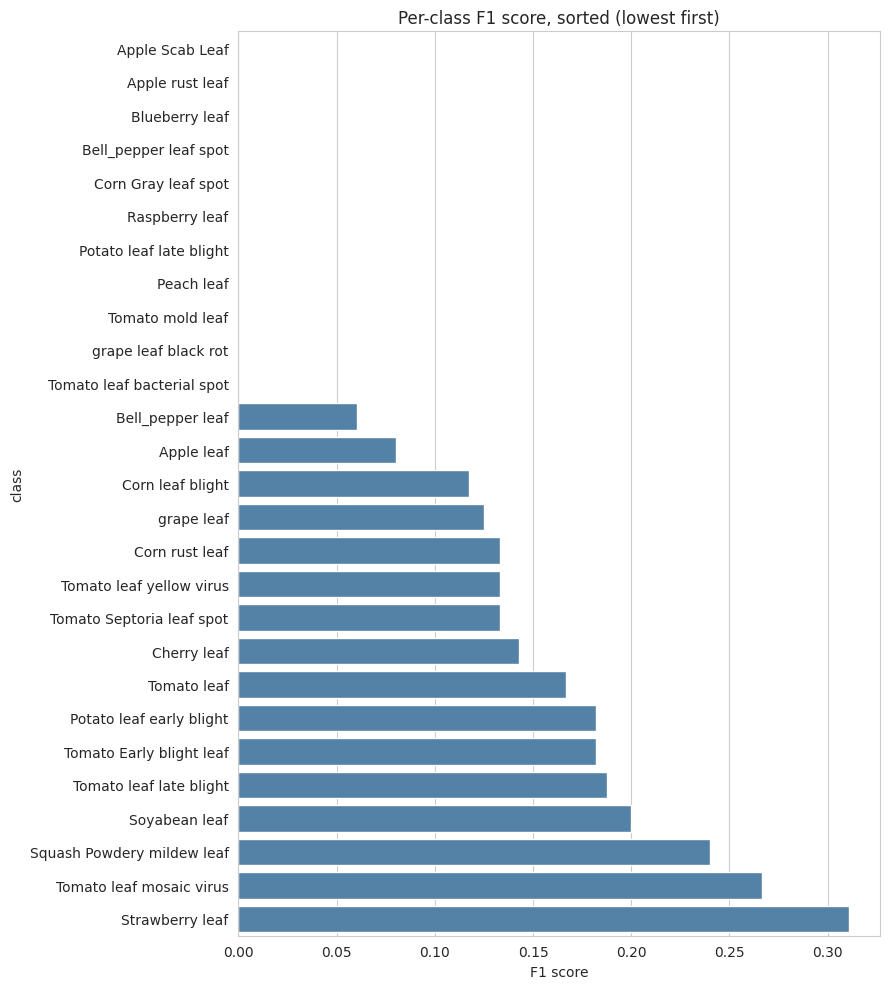

Classes with 0 test support (cannot be evaluated this run):
[]


In [44]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=np.arange(NUM_CLASSES), zero_division=0)

metrics_df = pd.DataFrame({
    "class": kept_class_names,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support,
}).sort_values("f1")

plt.figure(figsize=(9, 10))
sns.barplot(data=metrics_df, x="f1", y="class", color="steelblue")
plt.title("Per-class F1 score, sorted (lowest first)")
plt.xlabel("F1 score")
plt.tight_layout()
plt.show()

print("Classes with 0 test support (cannot be evaluated this run):")
print(metrics_df[metrics_df["support"] == 0]["class"].tolist())


## 38. Confusion Matrix

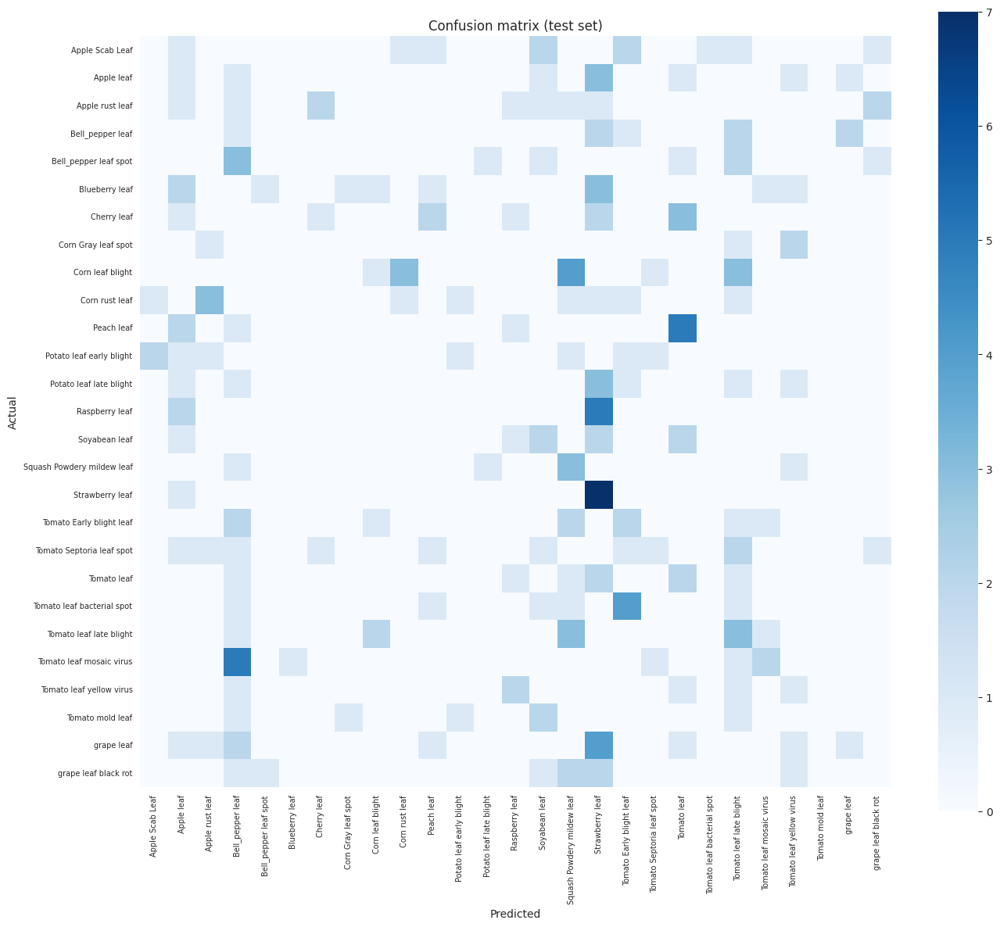

In [45]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(NUM_CLASSES))

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues",
            xticklabels=kept_class_names, yticklabels=kept_class_names,
            cbar=True, square=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix (test set)")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()


In [46]:
# Identify the most-confused class pairs (off-diagonal, excluding self-matches)
cm_no_diag = cm.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)

top_confusions = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm_no_diag[i, j] > 0:
            top_confusions.append((kept_class_names[i], kept_class_names[j], int(cm_no_diag[i, j])))

top_confusions = sorted(top_confusions, key=lambda x: -x[2])[:10]

print("Top confused pairs (actual -> predicted : count):")
for actual, predicted, count in top_confusions:
    print(f"  {actual}  ->  {predicted}  :  {count}")


Top confused pairs (actual -> predicted : count):
  Peach leaf  ->  Tomato leaf  :  5
  Raspberry leaf  ->  Strawberry leaf  :  5
  Tomato leaf mosaic virus  ->  Bell_pepper leaf  :  5
  Corn leaf blight  ->  Squash Powdery mildew leaf  :  4
  Tomato leaf bacterial spot  ->  Tomato Early blight leaf  :  4
  grape leaf  ->  Strawberry leaf  :  4
  Apple leaf  ->  Strawberry leaf  :  3
  Bell_pepper leaf spot  ->  Bell_pepper leaf  :  3
  Blueberry leaf  ->  Strawberry leaf  :  3
  Cherry leaf  ->  Tomato leaf  :  3


## 39. Sample Predictions

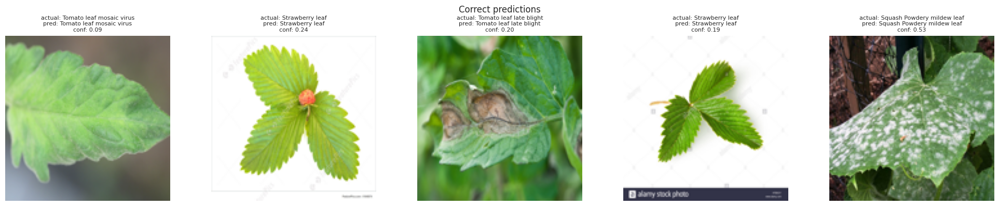

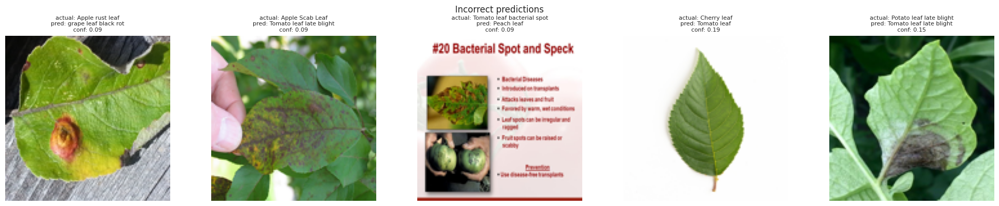

In [47]:
def show_prediction_grid(indices, title):
    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        ax.imshow(X_test[idx])
        actual = kept_class_names[y_test[idx]]
        predicted = kept_class_names[y_pred[idx]]
        conf = y_pred_conf[idx]
        ax.set_title(f"actual: {actual}\npred: {predicted}\nconf: {conf:.2f}", fontsize=8)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

correct_idx = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]

correct_sample = np.random.choice(correct_idx, size=min(5, len(correct_idx)), replace=False)
incorrect_sample = np.random.choice(incorrect_idx, size=min(5, len(incorrect_idx)), replace=False)

show_prediction_grid(correct_sample, "Correct predictions")
show_prediction_grid(incorrect_sample, "Incorrect predictions")
